# Breakout Room #4 — La curva Qini: ¿el modelo ordena de verdad?

**Objetivo:** construir la curva Qini y la tabla de deciles para comparar dos formas de
ordenar a los 14,000 clientes del experimento — por **riesgo/churn** y por **uplift
(T-learner)** — y ver cuál de las dos sirve de verdad para decidir a quién contactar.

Esta vez separamos los datos en dos partes: **entrenamiento** (para que los modelos
aprendan) y **prueba** (para evaluarlos con datos que nunca vieron — la misma idea de "las
dos ventanas" del Breakout 2, pero aplicada a modelos en vez de a fechas).

Donde dice **`# TODO`** hay algo para que ustedes completen.


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/uplift_experiment.csv")
FEATURES = ["recency_days", "frequency", "monetary", "email_open_rate"]

train, test = train_test_split(df, test_size=0.30, random_state=42, stratify=df["treatment_group"])
print(f"Entrenamiento: {len(train):,} clientes · Prueba: {len(test):,} clientes (el modelo nunca los ve)")


Entrenamiento: 9,800 clientes · Prueba: 4,200 clientes (el modelo nunca los ve)


## Paso 1 — entrenen los dos modelos (solo con datos de ENTRENAMIENTO)

- **`modelo_riesgo`**: un modelo de churn normal y corriente. No sabe nada de tratamiento/control
  — mezcla a todos los clientes de entrenamiento y aprende a predecir quién NO va a responder
  (`churned = 1 - responded_90d`). Así funcionaría un modelo de churn tradicional, el mismo tipo
  que construyeron en el Breakout 2.
- **`modelo_tratado`** y **`modelo_control`**: el T-learner de siempre (Breakout 3), entrenado
  solo con las filas de entrenamiento.


In [3]:
# TODO: entrenen modelo_riesgo prediciendo "churned" (1 - responded_90d) usando SOLO train

train = train.copy()

# Variable objetivo del modelo de riesgo
train["churned"] = 1 - train["responded_90d"]

# Modelo tradicional de riesgo/churn
modelo_riesgo = LogisticRegression(max_iter=1000)
modelo_riesgo.fit(
    train[FEATURES],
    train["churned"]
)

# Separar tratados y control SOLO dentro del entrenamiento
train_tratados = train[train["treatment_group"] == "treatment"]
train_control = train[train["treatment_group"] == "control"]

# Modelos del T-learner
modelo_tratado = LogisticRegression(max_iter=1000)
modelo_control = LogisticRegression(max_iter=1000)

modelo_tratado.fit(
    train_tratados[FEATURES],
    train_tratados["responded_90d"]
)

modelo_control.fit(
    train_control[FEATURES],
    train_control["responded_90d"]
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

## Paso 2 — puntúen el conjunto de PRUEBA (el que ningún modelo vio)

Igual que en el Breakout 3: le preguntan a los modelos sobre todos los clientes de prueba,
tratados y de control por igual.


In [4]:
test = test.copy()
X_test = test[FEATURES]

# TODO: calculen las tres probabilidades sobre el conjunto de prueba

test["prob_churn"] = modelo_riesgo.predict_proba(X_test)[:, 1]

test["p_tratado"] = modelo_tratado.predict_proba(X_test)[:, 1]
test["p_control"] = modelo_control.predict_proba(X_test)[:, 1]

test["uplift_estimado"] = (
    test["p_tratado"] - test["p_control"]
)

test[
    [
        "customer_id",
        "prob_churn",
        "p_tratado",
        "p_control",
        "uplift_estimado"
    ]
].head()

,customer_id,prob_churn,p_tratado,p_control,uplift_estimado
1514,1515,0.904556,0.109271,0.071850,0.037421
11250,11251,0.270724,0.826063,0.645906,0.180157
13938,13939,0.601709,0.465817,0.326372,0.139445
7824,7825,0.747900,0.358274,0.160365,0.197909
8723,8724,0.732951,0.362741,0.178745,0.183995


## Paso 3 — la curva Qini

Para cada corte N (del 2.5% al 100% de la base de prueba, ordenada de "mejor" a "peor" según el
modelo), midan:

```
ganancia(N) = (tasa de respuesta de los tratados en el top N  −  tasa de respuesta del control en el top N)  ×  N
```

Esa es la curva — compara contra la diagonal del azar. El **coeficiente Qini** es, sencillamente,
el área entre la curva del modelo y la diagonal del azar: entre más área (más arriba de la
diagonal), mejor ordena el modelo.


In [5]:
def curva_qini(test_df, score_col, steps=40):
    orden = test_df.sort_values(score_col, ascending=False).reset_index(drop=True)
    es_tratado = (orden["treatment_group"] == "treatment").values
    respondio = orden["responded_90d"].values

    acumulado_tratados = np.cumsum(np.where(es_tratado, respondio, 0))
    acumulado_control = np.cumsum(np.where(~es_tratado, respondio, 0))
    n_tratados_acum = np.cumsum(es_tratado)
    n_control_acum = np.cumsum(~es_tratado)

    n = len(orden)
    xs, ys = [0.0], [0.0]
    for i in np.linspace(1, n, steps).astype(int):
        nt, nc = n_tratados_acum[i - 1], n_control_acum[i - 1]
        tasa_t = acumulado_tratados[i - 1] / nt if nt > 0 else 0
        tasa_c = acumulado_control[i - 1] / nc if nc > 0 else 0
        xs.append(i / n)
        ys.append((tasa_t - tasa_c) * n)
    return np.array(xs), np.array(ys)


def coeficiente_qini(xs, ys):
    area_modelo = np.trapezoid(ys, xs)
    area_azar = np.trapezoid(np.linspace(0, ys[-1], len(xs)), xs)
    return (area_modelo - area_azar) / len(test)


xs_uplift, ys_uplift = curva_qini(test, "uplift_estimado")
xs_riesgo, ys_riesgo = curva_qini(test, "prob_churn")

qini_uplift = coeficiente_qini(xs_uplift, ys_uplift)
qini_riesgo = coeficiente_qini(xs_riesgo, ys_riesgo)

print(f"Coeficiente Qini · modelo de uplift (T-learner): {qini_uplift:+.3f}")
print(f"Coeficiente Qini · modelo de riesgo (churn):      {qini_riesgo:+.3f}")


Coeficiente Qini · modelo de uplift (T-learner): +0.222
Coeficiente Qini · modelo de riesgo (churn):      +0.006


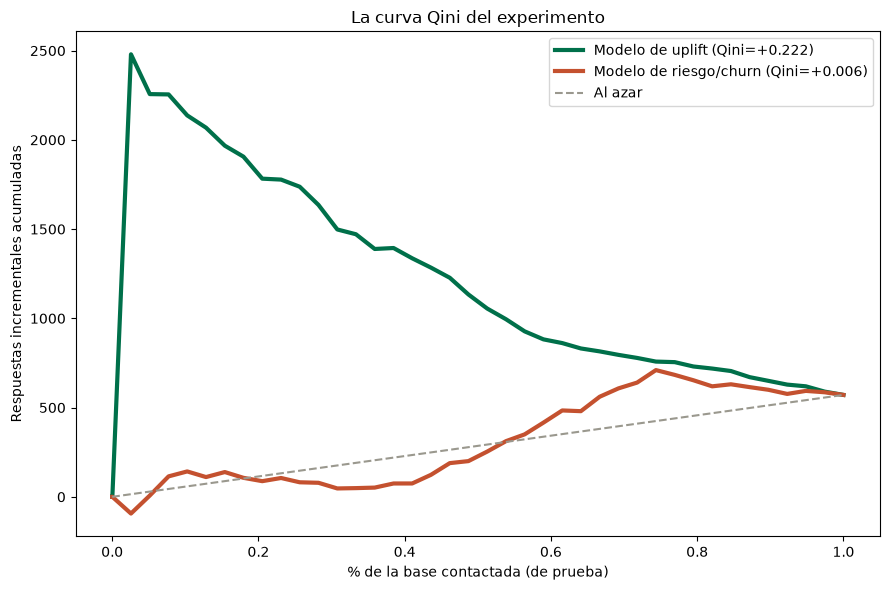

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(xs_uplift, ys_uplift, color="#00704A", linewidth=3, label=f"Modelo de uplift (Qini={qini_uplift:+.3f})")
ax.plot(xs_riesgo, ys_riesgo, color="#C4512F", linewidth=3, label=f"Modelo de riesgo/churn (Qini={qini_riesgo:+.3f})")
ax.plot([0, 1], [0, ys_uplift[-1]], color="#9A988E", linestyle="--", label="Al azar")
ax.set_xlabel("% de la base contactada (de prueba)")
ax.set_ylabel("Respuestas incrementales acumuladas")
ax.set_title("La curva Qini del experimento")
ax.legend()
plt.tight_layout()
plt.savefig("curva_qini.png", dpi=150)
plt.show()


## Paso 4 — la tabla de deciles: ¿el modelo ordena de verdad?

Dividan el conjunto de prueba en 10 deciles según `uplift_estimado` (decil 1 = uplift más alto
predicho). Para cada decil, comparen el uplift PREDICHO promedio contra el uplift REAL (tasa de
respuesta de tratados menos tasa de respuesta de control, DENTRO de ese decil).


In [7]:
test["decil"] = pd.qcut(test["uplift_estimado"], 10, labels=False, duplicates="drop")
test["decil"] = 9 - test["decil"]  # decil 1 = el de mayor uplift predicho

filas = []
for d in range(10):
    grp = test[test["decil"] == d]
    pred = grp["uplift_estimado"].mean()
    real_t = grp.loc[grp["treatment_group"] == "treatment", "responded_90d"].mean()
    real_c = grp.loc[grp["treatment_group"] == "control", "responded_90d"].mean()
    filas.append({"decil": d + 1, "uplift_predicho": round(pred, 3), "uplift_real": round(real_t - real_c, 3), "n": len(grp)})

tabla_deciles = pd.DataFrame(filas)
tabla_deciles


,decil,uplift_predicho,uplift_real,n
0,1,0.394,0.505,420
1,2,0.286,0.347,420
2,3,0.216,0.241,420
3,4,0.168,0.199,420
4,5,0.129,0.051,420
5,6,0.099,-0.059,420
6,7,0.074,0.078,420
7,8,0.053,0.054,420
8,9,0.031,0.022,420
9,10,-0.009,-0.022,420


## Para la Clase

### 1. ¿El coeficiente Qini del modelo de riesgo/churn es mayor, menor o parecido al del modelo de uplift? ¿Qué dice eso sobre usar un modelo de churn para decidir a quién contactar?

El coeficiente Qini del modelo de riesgo/churn fue **mucho menor** que el del modelo de uplift:

- **Modelo de uplift (T-learner): +0.222**
- **Modelo de riesgo/churn: +0.006**

Esto indica que el modelo de uplift ordena mucho mejor a los clientes según el beneficio incremental que puede generar el tratamiento. En cambio, el modelo de churn tiene un desempeño muy cercano al azar para esta tarea.

Por lo tanto, un modelo de churn puede servir para identificar quién tiene riesgo de no responder, pero **no necesariamente identifica a quién conviene contactar**, porque no mide el efecto que tendrá la intervención sobre cada cliente.

### 2. ¿Hay algún decil donde lo predicho y lo real se alejan mucho? Con ~420 clientes por decil, ¿qué tan confiables son esos números?

Sí. El **decil 6** presenta la mayor diferencia:

- Uplift predicho: **+0.099**
- Uplift real: **-0.059**

El modelo esperaba un efecto positivo, pero en los datos reales el tratamiento tuvo un efecto ligeramente negativo.

También existe cierta diferencia en el **decil 1**, donde el uplift predicho fue **+0.394** y el real fue **+0.505**.

Aunque cada decil contiene aproximadamente **420 clientes**, estos resultados todavía pueden presentar variación, porque dentro de cada decil los clientes se dividen entre tratamiento y control. Por eso no debemos esperar que el uplift real coincida exactamente con el predicho en cada grupo. Lo más importante es observar la tendencia general: los primeros deciles presentan un uplift mayor y los últimos uno mucho menor o incluso negativo.

### 3. ¿Cómo explicaríamos el coeficiente Qini a alguien de negocio en una frase?

El **coeficiente Qini mide qué tan bien el modelo logra priorizar a los clientes en los que una campaña realmente genera un efecto adicional, comparado con seleccionarlos al azar**.